# Brain Trait Analysis
**RQ**: How different are the brain traits (phase + amplitude per muscle voxel) between parents and children?

Brain traits are GRN-derived per-voxel values:
- **Phase** [0, 2π]: when each muscle peaks in its contraction cycle (TF7)
- **Amplitude** [0.1, 0.6]: how strongly each muscle contracts (TF6)

We summarise each robot's brain as `(phase_mean, phase_std, amp_mean, amp_std)` across all muscle voxels, then compute Euclidean distance between parent and child summaries.

## 0. Setup

In [ ]:
import sys
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# point to the repo root so GRN imports work
REPO_ROOT = Path(".").resolve()  # run this notebook from evogym-GRN/
sys.path.append(str(REPO_ROOT))

from algorithms.GRN_2D import GRN, initialization
from algorithms.voxel_types import VOXEL_TYPES

print("Imports OK")

Imports OK


## 1. Run an Experiment

Run this command in a terminal (not here — it takes a few minutes):

```bash
conda activate evogym
cd evogym-GRN
python algorithms/basic_EA.py \
  --study_name thesis \
  --experiment_name run_medium \
  --run 1 \
  --population_size 30 \
  --offspring_size 30 \
  --num_generations 30 \
  --run_simulation 1
```

Once it finishes, set `DB_PATH` below to point at the resulting database file.

## 2. Load Data

In [ ]:
# ---------- CONFIGURE THIS FOR DIFFERENT EXPERIMENTS ----------
STUDY_NAME      = "thesis"
OUT_PATH        = "tmp_out"
VOXEL_TYPES_KEY = "withbone"

# condition_label -> (experiment_name, n_runs)
EXPERIMENTS = {
    "tf67":     ("cmp500_tf67",     10),
    "original": ("cmp500_original", 10),
}
# ------------------------------------

import json


def load_experiment(study_name, experiment_name, n_runs, condition, out_path=OUT_PATH):
    """
    Load all_robots + generation_survivors for every run of one experiment,
    tag everything with `condition`, and build cross-condition-safe uids.
    """
    all_robots    = []
    all_survivors = []

    for run in range(1, n_runs + 1):
        db_path = f"{out_path}/{study_name}/{experiment_name}/run_{run}/run_{run}"
        con = sqlite3.connect(db_path)

        r_df = pd.read_sql("""
            SELECT robot_id, born_generation, genome,
                   parent1_id, parent2_id,
                   displacement, num_voxels,
                   phase_muscle_count, offphase_muscle_count
            FROM all_robots
        """, con)

        s_df = pd.read_sql("""
            SELECT generation, robot_id, fitness, novelty, novelty_weighted
            FROM generation_survivors
        """, con)

        con.close()

        r_df["run"] = run
        s_df["run"] = run
        all_robots.append(r_df)
        all_survivors.append(s_df)

    r_df = pd.concat(all_robots,    ignore_index=True)
    s_df = pd.concat(all_survivors, ignore_index=True)

    r_df["condition"] = condition
    s_df["condition"] = condition

    # genome is stored as JSON string -> parse it
    r_df["genome"] = r_df["genome"].apply(
        lambda g: json.loads(g) if isinstance(g, str) else g
    )

    # uid includes condition + run, since both conditions reuse run=1..N and
    # robot_ids are only unique within a single run's DB
    def make_uid(condition, run, id_val):
        if pd.isna(id_val):
            return None
        return f"{condition}_{int(run)}_{int(id_val)}"

    r_df["uid"]         = r_df.apply(lambda r: make_uid(r["condition"], r["run"], r["robot_id"]),  axis=1)
    r_df["parent1_uid"] = r_df.apply(lambda r: make_uid(r["condition"], r["run"], r["parent1_id"]), axis=1)
    r_df["parent2_uid"] = r_df.apply(lambda r: make_uid(r["condition"], r["run"], r["parent2_id"]), axis=1)

    return r_df, s_df


all_robots_list    = []
all_survivors_list = []
for condition, (experiment_name, n_runs) in EXPERIMENTS.items():
    r_df, s_df = load_experiment(STUDY_NAME, experiment_name, n_runs, condition)
    all_robots_list.append(r_df)
    all_survivors_list.append(s_df)
    print(f"[{condition}] robots: {len(r_df)}  survivors: {len(s_df)}  "
          f"generations: {s_df['generation'].nunique()}  runs: {r_df['run'].nunique()}")

robots_df    = pd.concat(all_robots_list,    ignore_index=True)
survivors_df = pd.concat(all_survivors_list, ignore_index=True)

print(f"\nTotal robots:    {len(robots_df)}")
print(f"Total survivors: {len(survivors_df)}")
robots_df.head()

[tf67] robots: 150000  survivors: 150000  generations: 500  runs: 10
[original] robots: 150000  survivors: 150000  generations: 500  runs: 10

Total robots:    300000
Total survivors: 300000


,robot_id,born_generation,genome,parent1_id,parent2_id,displacement,num_voxels,phase_muscle_count,offphase_muscle_count,run,condition,uid,parent1_uid,parent2_uid
0,1,1,"[0.52, 0.64, 0.33, 0.1, 0.91, 0.7, 0.18, 0.59,...",NaN,NaN,0.083593,7.0,4.0,2.0,1,tf67,tf67_1_1,None,None
1,2,1,"[0.79, 0.23, 0.27, 0.28, 0.39, 0.49, 0.67, 0.9...",NaN,NaN,0.563774,9.0,2.0,3.0,1,tf67,tf67_1_2,None,None
2,3,1,"[0.86, 0.89, 0.32, 0.31, 0.26, 0.81, 0.96, 0.2...",NaN,NaN,0.989692,4.0,1.0,1.0,1,tf67,tf67_1_3,None,None
3,4,1,"[0.59, 0.79, 0.01, 0.12, 0.61, 0.14, 0.55, 0.5...",NaN,NaN,8.794130,12.0,2.0,1.0,1,tf67,tf67_1_4,None,None
4,5,1,"[0.31, 0.55, 0.03, 0.73, 0.96, 0.18, 0.7, 0.6,...",NaN,NaN,-inf,1.0,0.0,1.0,1,tf67,tf67_1_5,None,None


### 2b. Sanity check: is `fitness` actually `displacement`, or is `novelty` influencing it?

`generation_survivors.fitness` is whatever `fitness_metric` was set to for this run
(`utils/config.py`, default `"displacement"`). `novelty` / `novelty_weighted` are computed and
stored every generation regardless, but they only affect selection if `fitness_metric` was set
to one of them. This cell checks directly, for this dataset, which one `fitness` actually equals.

In [ ]:
check = survivors_df.merge(
    robots_df[["robot_id", "run", "condition", "displacement"]], on=["robot_id", "run", "condition"]
)

finite = np.isfinite(check["fitness"]) & np.isfinite(check["displacement"])
eq_to_displacement     = (check["fitness"] == check["displacement"]).mean()
eq_to_novelty_weighted = (check["fitness"] == check["novelty_weighted"]).mean()

print(f"fraction of survivor rows where fitness == displacement:      {eq_to_displacement:.3f}")
print(f"fraction of survivor rows where fitness == novelty_weighted:  {eq_to_novelty_weighted:.3f}")
print()
print("=> fitness_metric used for these runs was:",
      "'displacement'" if eq_to_displacement > 0.99 else
      "'novelty_weighted'" if eq_to_novelty_weighted > 0.99 else
      "something else (check utils/config.py / the run's params file)")

print()
print("novelty (computed every generation, but NOT used as fitness here), by condition:")
for condition, group in check.groupby("condition"):
    g_finite = np.isfinite(group["fitness"]) & np.isfinite(group["novelty"])
    print(f"  [{condition}] novelty mean={group['novelty'].mean():.3f}  "
          f"corr(fitness, novelty)={group.loc[g_finite, 'fitness'].corr(group.loc[g_finite, 'novelty']):.3f}")

fraction of survivor rows where fitness == displacement:      1.000
fraction of survivor rows where fitness == novelty_weighted:  0.001

=> fitness_metric used for these runs was: 'displacement'

novelty (computed every generation, but NOT used as fitness here), by condition:
  [original] novelty mean=0.102  corr(fitness, novelty)=-0.694
  [tf67] novelty mean=0.080  corr(fitness, novelty)=-0.595


## 3. Re-derive Brain Traits

Phase and amplitude maps are not stored in the DB - we re-derive them from each robot's genome using the GRN.

`GRN.develop()` always computes `phase_map`/`amplitude_map` from TF6/TF7, **regardless of
`use_grn_brain_traits`** (that flag only controls whether `prepare_robot_files` passes these
maps to the controller vs falling back to fixed/binary phase=0/π and amplitude=0.4).

So for the **`original`** condition, the brain traits computed here represent TF6/TF7 signal
that exists in the genome/GRN but did **NOT** drive the controller during simulation. 
This lets us test whether the brain_dist <-> disp_improvement relationship found for
`tf67` is tied to TF6/TF7 actually controlling behaviour, or whether a similar pattern appears
even when that signal is inert.

In [ ]:
import multiprocessing as mp

def brain_summary(genome, voxel_types_key="withbone"):
    """
    Re-run GRN development and extract brain trait summaries:
    (phase_mean, phase_std, amp_mean, amp_std) over all muscle voxels.
    Returns (NaN, NaN, NaN, NaN) if no muscles.
    """
    grn = GRN(
        promoter_threshold=0.95,
        max_voxels=27, # should be 16 but it doesn't matter cause cube_face_size already caps it at 16
        cube_face_size=4,  # must match the final_200 EA run -> verified vs stored num_voxels = 16 = 4x4
        voxel_types=voxel_types_key,
        genotype=list(genome),
    )
    grn.develop()

    muscle_types = {
        grn.structural_products.get("phase_muscle"),
        grn.structural_products.get("offphase_muscle"),
    }
    muscle_mask = np.zeros(grn.phenotype.shape, dtype=bool)
    for idx, cell in np.ndenumerate(grn.phenotype):
        if cell != 0 and cell.voxel_type in muscle_types:
            muscle_mask[idx] = True

    if not muscle_mask.any():
        return np.nan, np.nan, np.nan, np.nan

    phases = grn.phase_map[muscle_mask]
    amps   = grn.amplitude_map[muscle_mask]

    return float(phases.mean()), float(phases.std()), float(amps.mean()), float(amps.std())


def _brain_summary_worker(args):
    genome, key = args
    return brain_summary(genome, key)


n_workers  = mp.cpu_count()
n_robots   = len(robots_df)
batch_size = 10_000
print(f"Deriving brain traits for {n_robots:,} robots using {n_workers} workers ...")

args      = list(zip(robots_df["genome"], [VOXEL_TYPES_KEY] * n_robots))
summaries = []
done      = 0

ctx = mp.get_context("fork")
with ctx.Pool(n_workers) as pool:
    for start in range(0, n_robots, batch_size):
        chunk = args[start : start + batch_size]
        summaries.extend(pool.map(_brain_summary_worker, chunk, chunksize=200))
        done += len(chunk)
        print(f"  {done:,} / {n_robots:,}  ({100 * done / n_robots:.1f}%)")

robots_df[["phase_mean", "phase_std", "amp_mean", "amp_std"]] = pd.DataFrame(
    summaries, index=robots_df.index
)
print("Done.")
robots_df[["robot_id", "born_generation", "phase_mean", "phase_std", "amp_mean", "amp_std", "displacement"]].head(10)

Deriving brain traits for 300,000 robots using 10 workers ...
  10,000 / 300,000  (3.3%)
  20,000 / 300,000  (6.7%)
  30,000 / 300,000  (10.0%)
  40,000 / 300,000  (13.3%)
  50,000 / 300,000  (16.7%)
  60,000 / 300,000  (20.0%)
  70,000 / 300,000  (23.3%)
  80,000 / 300,000  (26.7%)
  90,000 / 300,000  (30.0%)
  100,000 / 300,000  (33.3%)
  110,000 / 300,000  (36.7%)
  120,000 / 300,000  (40.0%)
  130,000 / 300,000  (43.3%)
  140,000 / 300,000  (46.7%)
  150,000 / 300,000  (50.0%)
  160,000 / 300,000  (53.3%)
  170,000 / 300,000  (56.7%)
  180,000 / 300,000  (60.0%)
  190,000 / 300,000  (63.3%)
  200,000 / 300,000  (66.7%)
  210,000 / 300,000  (70.0%)
  220,000 / 300,000  (73.3%)
  230,000 / 300,000  (76.7%)
  240,000 / 300,000  (80.0%)
  250,000 / 300,000  (83.3%)
  260,000 / 300,000  (86.7%)
  270,000 / 300,000  (90.0%)
  280,000 / 300,000  (93.3%)
  290,000 / 300,000  (96.7%)
  300,000 / 300,000  (100.0%)
Done.


,robot_id,born_generation,phase_mean,phase_std,amp_mean,amp_std,displacement
0,1,1,2.459204,2.753209,0.100000,0.000000,0.083593
1,2,1,0.000000,0.000000,0.306134,0.239354,0.563774
2,3,1,3.141593,3.141593,0.350000,0.250000,0.989692
3,4,1,2.094395,2.961922,0.405495,0.218691,8.794130
4,5,1,0.000000,0.000000,0.100000,0.000000,-inf
5,6,1,0.000000,0.000000,0.100000,0.000000,-0.031635
6,7,1,0.000000,0.000000,0.100000,0.000000,0.577014
7,8,1,3.141593,3.141593,0.100000,0.000000,-0.015181
8,9,1,0.000000,0.000000,0.100000,0.000000,-inf
9,10,1,2.591223,2.680588,0.398387,0.215289,-2.968426


## 4. Compute Parent–Child Brain Trait Distance

Phase (range ≈ [0, 2π]) and amplitude (range ≈ [0.1, 0.6]) live on very different scales. A raw
Euclidean distance over the concatenated `(phase_mean, phase_std, amp_mean, amp_std)` vector would be
dominated by whichever variable has the larger absolute range — phase, in this case (this is also why
naive `brain_dist` correlates almost perfectly with `phase_dist` but weakly with `amp_dist`).

To make the four trait dimensions comparable, we **standardize each one across the population**
(z-score: $z = (x - \mu_{\text{pop}}) / \sigma_{\text{pop}}$), then compute the Euclidean distance
between the standardized parent and child summaries:
$$d = \sqrt{(\Delta z_{\mu_\phi})^2 + (\Delta z_{\sigma_\phi})^2 + (\Delta z_{\mu_A})^2 + (\Delta z_{\sigma_A})^2}$$

where $\phi$ = phase and $A$ = amplitude. Standardizing features before computing distance is
standard practice whenever the underlying variables are on different scales/units (see e.g. Hastie,
Tibshirani & Friedman, *The Elements of Statistical Learning*, ch. 13–14 on distance-based methods).

In [ ]:
BRAIN_COLS = ["phase_mean", "phase_std", "amp_mean", "amp_std"]

# Phase (range ~[0, 2π]) and amplitude (range ~[0.1, 0.6]) live on very different
# scales, so a raw Euclidean norm over the concatenated vector is dominated by
# phase (see the brain_dist/phase_dist correlation of ~1.0 vs ~0.27 for amp_dist
# in the summary below). Z-score each trait dimension across the population first
# so all four contribute comparably to the distance.

# Z-scoring is done PER CONDITION: "tf67" and "original" robots may have
# differently shaped brain trait distributions (the controller only consumes
# TF6/TF7 in "tf67", which can shape what the EA selects for) 
# and every parent-child pair lives entirely within one condition anyway
group_mean = robots_df.groupby("condition")[BRAIN_COLS].transform("mean")
group_std  = robots_df.groupby("condition")[BRAIN_COLS].transform("std")

robots_z = robots_df.copy()
robots_z[BRAIN_COLS] = (robots_df[BRAIN_COLS] - group_mean) / group_std

id_to_summary = robots_z.set_index("uid")[
    BRAIN_COLS + ["born_generation", "displacement", "condition"]
].to_dict("index")

rows = []
skipped_inf = 0
for _, child in robots_z.iterrows():
    for parent_uid_col in ["parent1_uid", "parent2_uid"]:
        puid = child[parent_uid_col]
        if pd.isna(puid) or puid not in id_to_summary:
            continue

        child_vec  = np.array([child[c] for c in BRAIN_COLS], dtype=float)
        parent_vec = np.array([id_to_summary[puid][c] for c in BRAIN_COLS], dtype=float)

        if np.any(np.isnan(child_vec)) or np.any(np.isnan(parent_vec)):
            continue

        child_disp  = child["displacement"]
        parent_disp = id_to_summary[puid]["displacement"]

        # skip pairs where either robot's simulation failed => displacement = -inf
        # else disp_improvement becomes -inf/NaN and silently corrupts the
        # .corr() calls in section 5 (pandas treats -inf as a finite value there => produces meaningless results
        if not (np.isfinite(child_disp) and np.isfinite(parent_disp)):
            skipped_inf += 1
            continue

        dist       = float(np.linalg.norm(child_vec - parent_vec))
        phase_dist = float(np.linalg.norm(child_vec[:2] - parent_vec[:2]))
        amp_dist   = float(np.linalg.norm(child_vec[2:] - parent_vec[2:]))

        rows.append({
            "run":         child["run"],
            "condition":   child["condition"],
            "child_uid":   child["uid"],
            "parent_uid":  puid,
            "generation":  child["born_generation"],
            "brain_dist":  dist,
            "phase_dist":  phase_dist,
            "amp_dist":    amp_dist,
            "child_disp":  child_disp,
            "parent_disp": parent_disp,
        })

pairs_df = pd.DataFrame(rows)
pairs_df["disp_improvement"] = pairs_df["child_disp"] - pairs_df["parent_disp"]

print(f"Parent-child pairs: {len(pairs_df)} across {pairs_df['run'].nunique()} runs "
      f"and {pairs_df['condition'].nunique()} conditions")
print(f"Skipped pairs (a robot's displacement was -inf, i.e. failed simulation): {skipped_inf}")
for condition, group in pairs_df.groupby("condition"):
    print(f"  [{condition}] pairs: {len(group)}  generations: {group['generation'].nunique()}")
pairs_df.head(10)

Parent-child pairs: 488118 across 10 runs and 2 conditions
Skipped pairs (a robot's displacement was -inf, i.e. failed simulation): 110682
  [original] pairs: 249484  generations: 499
  [tf67] pairs: 238634  generations: 499


,run,condition,child_uid,parent_uid,generation,brain_dist,phase_dist,amp_dist,child_disp,parent_disp,disp_improvement
0,1,tf67,tf67_1_31,tf67_1_4,2,1.964989,1.208626,1.549324,2.526152,8.794130,-6.267977
1,1,tf67,tf67_1_31,tf67_1_13,2,1.063297,0.761828,0.741768,2.526152,2.775375,-0.249223
2,1,tf67,tf67_1_33,tf67_1_7,2,2.957937,0.000000,2.957937,3.122361,0.577014,2.545347
3,1,tf67,tf67_1_33,tf67_1_4,2,2.653175,2.629889,0.350745,3.122361,8.794130,-5.671769
4,1,tf67,tf67_1_34,tf67_1_4,2,4.114548,2.629889,3.164363,-0.002683,8.794130,-8.796813
5,1,tf67,tf67_1_34,tf67_1_19,2,3.691102,2.629889,2.589965,-0.002683,5.635185,-5.637868
6,1,tf67,tf67_1_35,tf67_1_1,2,0.710361,0.710361,0.000000,0.604616,0.083593,0.521024
7,1,tf67,tf67_1_35,tf67_1_26,2,3.661466,2.046435,3.036188,0.604616,2.053742,-1.449126
8,1,tf67,tf67_1_36,tf67_1_7,2,0.000000,0.000000,0.000000,-0.505254,0.577014,-1.082267
9,1,tf67,tf67_1_36,tf67_1_13,2,3.810916,2.813825,2.570111,-0.505254,2.775375,-3.280629


## 5. Visualise

In [ ]:
# helper mean ± std ribbon
def ribbon_plot(ax, df, x_col, y_col, color, label):
    stats = df.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
    ax.plot(stats[x_col], stats["mean"], color=color, label=label)
    ax.fill_between(
        stats[x_col],
        stats["mean"] - stats["std"],
        stats["mean"] + stats["std"],
        alpha=0.2, color=color
    )
    return stats

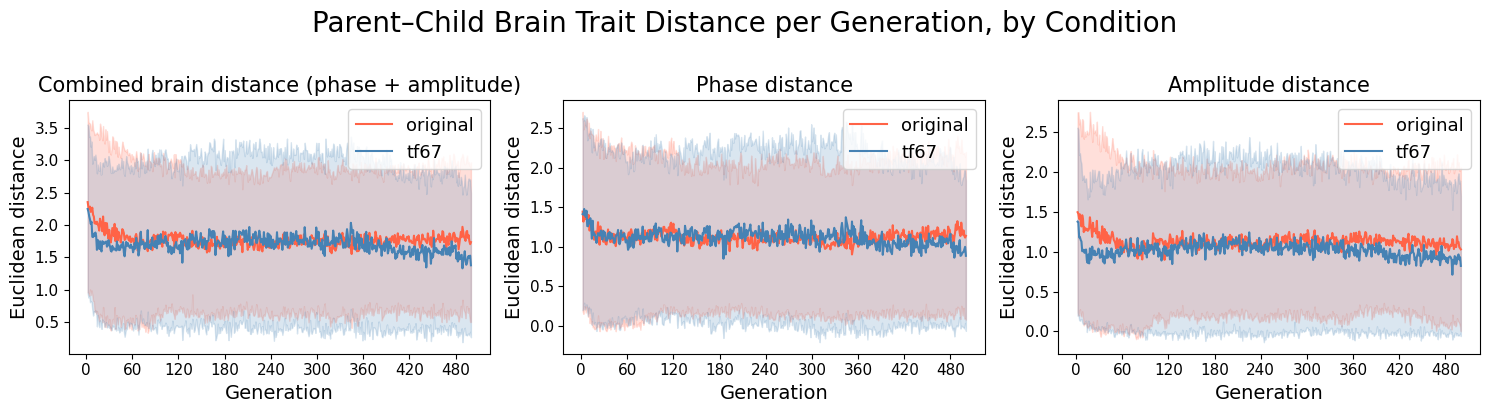

In [ ]:
# ── Plot 1: Brain trait distance over generations by condition ───────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

CONDITION_COLORS = {"tf67": "steelblue", "original": "tomato"}

for condition, group in pairs_df.groupby("condition"):
    color = CONDITION_COLORS.get(condition, "gray")
    ribbon_plot(axes[0], group, "generation", "brain_dist", color, condition)
    ribbon_plot(axes[1], group, "generation", "phase_dist", color, condition)
    ribbon_plot(axes[2], group, "generation", "amp_dist",   color, condition)

axes[0].set_title("Combined brain distance (phase + amplitude)", fontsize=15)
axes[1].set_title("Phase distance", fontsize=15)
axes[2].set_title("Amplitude distance", fontsize=15)

for ax in axes:
    ax.set_xlabel("Generation", fontsize=14)
    ax.set_ylabel("Euclidean distance", fontsize=14)
    ax.tick_params(axis='both', labelsize=11)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=13)

fig.suptitle("Parent–Child Brain Trait Distance per Generation, by Condition", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

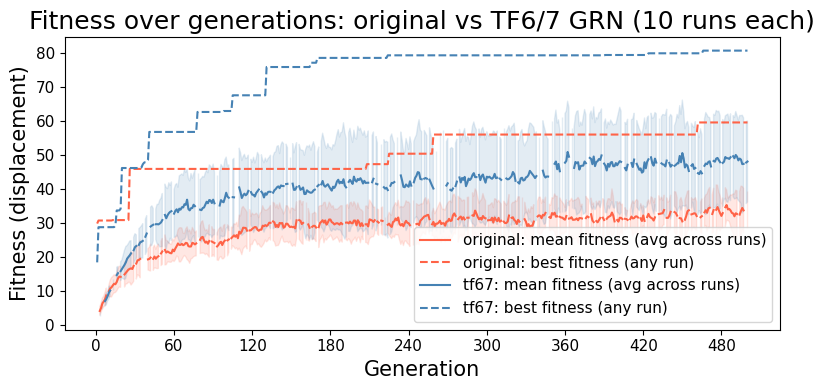

In [ ]:
# ── Plot 2: Fitness over generations by condition (mean across runs) ─────────
fig, ax = plt.subplots(figsize=(8, 4))

CONDITION_COLORS = {"tf67": "steelblue", "original": "tomato"}

for condition, group in survivors_df.groupby("condition"):
    color = CONDITION_COLORS.get(condition, "gray")

    gen_run   = group.groupby(["run", "generation"])["fitness"].mean().reset_index()
    gen_stats = gen_run.groupby("generation")["fitness"].agg(["mean", "std"]).reset_index()

    ax.plot(gen_stats["generation"], gen_stats["mean"], color=color,
            label=f"{condition}: mean fitness (avg across runs)")
    ax.fill_between(
        gen_stats["generation"],
        gen_stats["mean"] - gen_stats["std"],
        gen_stats["mean"] + gen_stats["std"],
        alpha=0.15, color=color,
    )

    best = group.groupby("generation")["fitness"].max().reset_index()
    ax.plot(best["generation"], best["fitness"], color=color, linestyle="--",
            label=f"{condition}: best fitness (any run)")

ax.set_xlabel("Generation", fontsize=15)
ax.set_ylabel("Fitness (displacement)", fontsize=15)
ax.set_title("Fitness over generations: original vs TF6/7 GRN (10 runs each)", fontsize=18)
ax.legend(fontsize=11)
ax.tick_params(axis='both', labelsize=11)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

In [13]:
# ── Diagnostic: survivors per generation per run, by condition ────────────────
for condition, group in survivors_df.groupby("condition"):
    gen_counts = group.groupby(["generation", "run"]).size().unstack(fill_value=0)
    n_missing = (gen_counts == 0).any(axis=1).sum()
    print(f"[{condition}] generations: {len(gen_counts)}  runs: {gen_counts.shape[1]}  "
          f"generations with any run missing data: {n_missing} / {len(gen_counts)}")

[original] generations: 500  runs: 10  generations with any run missing data: 0 / 500
[tf67] generations: 500  runs: 10  generations with any run missing data: 0 / 500


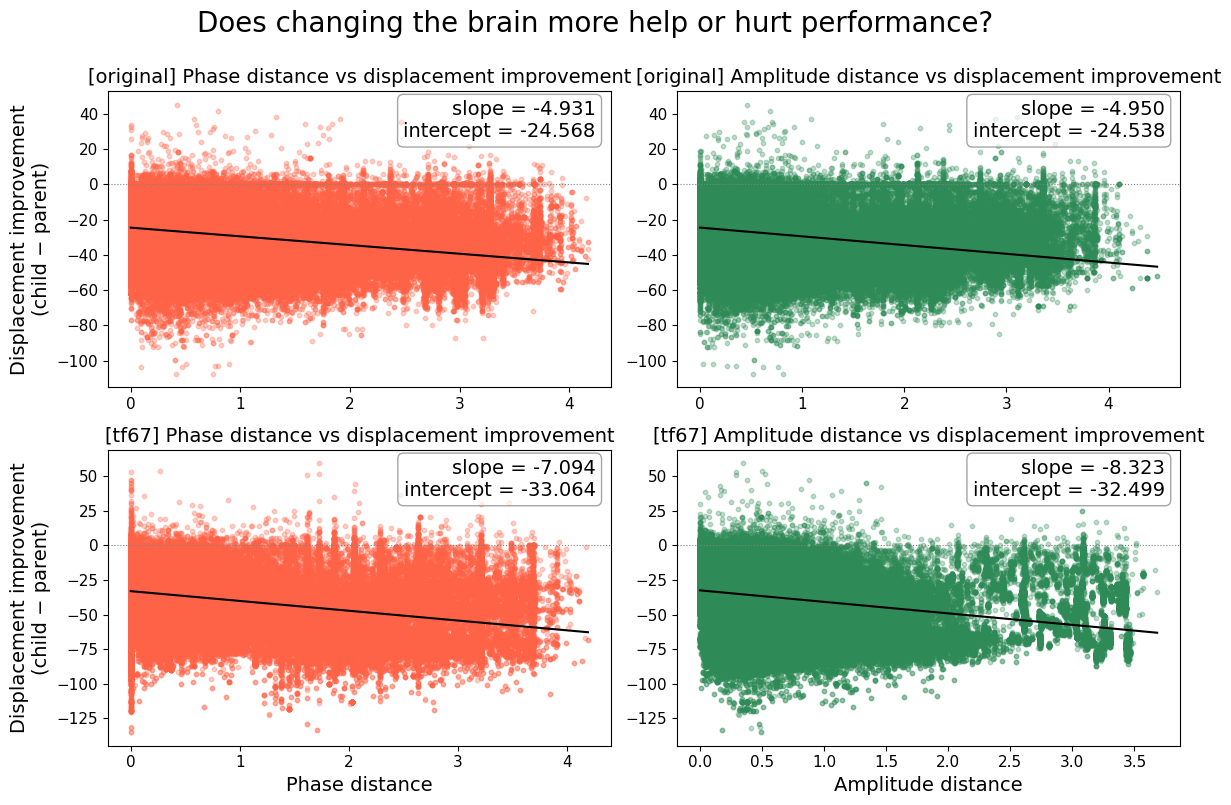

In [39]:
# ── Plot 3: Does brain distance correlate with displacement improvement? ───────
conditions = sorted(pairs_df["condition"].unique())
last_row = len(conditions) - 1
fig, axes = plt.subplots(len(conditions), 2, figsize=(12, 4 * len(conditions)), squeeze=False)

for row, condition in enumerate(conditions):
    group = pairs_df[pairs_df["condition"] == condition]

    for col, (dist_col, color, label) in enumerate([
        ("phase_dist", "tomato",   "Phase distance"),
        ("amp_dist",   "seagreen", "Amplitude distance"),
    ]):
        ax = axes[row][col]
        ax.scatter(group[dist_col], group["disp_improvement"],
                   alpha=0.3, s=10, color=color)

        valid = group[[dist_col, "disp_improvement"]].dropna()
        if len(valid) > 1:
            m, b = np.polyfit(valid[dist_col], valid["disp_improvement"], 1)
            x_range = np.linspace(valid[dist_col].min(), valid[dist_col].max(), 100)
            ax.plot(x_range, m * x_range + b, color="black", linewidth=1.5)
            ax.text(0.97, 0.97,
                    f"slope = {m:.3f}\nintercept = {b:.3f}",
                    transform=ax.transAxes,
                    ha="right", va="top",
                    fontsize=14, color="black",
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="gray"))

        ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
        ax.set_title(f"[{condition}] {label} vs displacement improvement", fontsize=14)
        ax.tick_params(axis='both', labelsize=11)

        # xlabel only on the bottom row
        if row == last_row:
            ax.set_xlabel(label, fontsize=14)
        else:
            ax.set_xlabel("")

        # ylabel only on the left column
        if col == 0:
            ax.set_ylabel("Displacement improvement\n(child − parent)", fontsize=14)
        else:
            ax.set_ylabel("")

fig.suptitle("Does changing the brain more help or hurt performance?", fontsize=20, y=1.0)
plt.tight_layout()
plt.show()

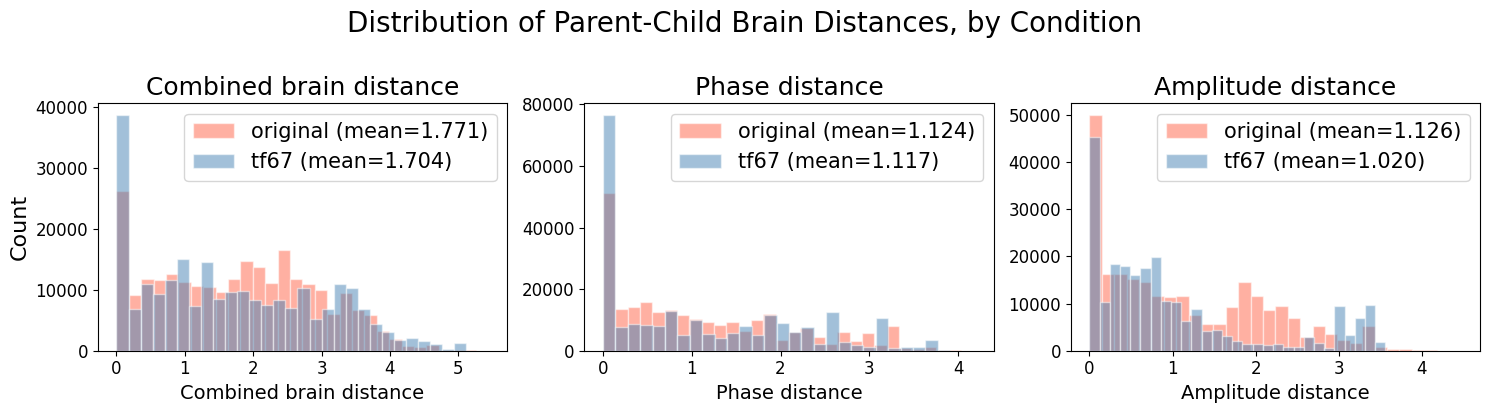

In [60]:
# ── Plot 4: Distribution of brain distances, by condition ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

CONDITION_COLORS = {"tf67": "steelblue", "original": "tomato"}

for i, (ax, col, title) in enumerate([
    (axes[0], "brain_dist",  "Combined brain distance"),
    (axes[1], "phase_dist",  "Phase distance"),
    (axes[2], "amp_dist",    "Amplitude distance"),
]):
    for condition, group in pairs_df.groupby("condition"):
        color = CONDITION_COLORS.get(condition, "gray")
        ax.hist(group[col].dropna(), bins=30, color=color, alpha=0.5, edgecolor="white",
                label=f"{condition} (mean={group[col].mean():.3f})")
    ax.set_xlabel(title, fontsize=14)
    ax.set_ylabel("Count" if i == 0 else "", fontsize=16)
    ax.set_title(title, fontsize=18)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=15)

fig.suptitle("Distribution of Parent-Child Brain Distances, by Condition", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

In [62]:
# ── Summary ────────────────────────────────────────────────────────
print("=== Parent-Child Brain Distance Summary, by condition ===")
for condition, group in pairs_df.groupby("condition"):
    print(f"\n[{condition}]")
    print(group[["brain_dist", "phase_dist", "amp_dist"]].describe().round(4))

print("\n=== Correlation with displacement improvement, by condition ===")
corr_rows = {}
for condition, group in pairs_df.groupby("condition"):
    corr_rows[condition] = group[["brain_dist", "phase_dist", "amp_dist"]].corrwith(group["disp_improvement"])
corr_table = pd.DataFrame(corr_rows).T
corr_table.index.name = "condition"
print(corr_table.round(3))

=== Parent-Child Brain Distance Summary, by condition ===

[original]
        brain_dist   phase_dist     amp_dist
count  249484.0000  249484.0000  249484.0000
mean        1.7709       1.1238       1.1255
std         1.1533       0.9960       0.9719
min         0.0000       0.0000       0.0000
25%         0.7772       0.2581       0.2603
50%         1.8119       0.8807       0.9064
75%         2.6207       1.8354       1.8706
max         5.4425       4.1693       4.4756

[tf67]
        brain_dist   phase_dist     amp_dist
count  238634.0000  238634.0000  238634.0000
mean        1.7042       1.1175       1.0204
std         1.2914       1.0968       1.0388
min         0.0000       0.0000       0.0000
25%         0.5946       0.0000       0.2755
50%         1.5109       0.7608       0.6754
75%         2.7286       2.0423       1.3282
max         5.2961       4.1904       3.6828

=== Correlation with displacement improvement, by condition ===
           brain_dist  phase_dist  amp_dist
con